# Fit NASA9 Polynomials to Gibbs Free Energy (G vs T)

This notebook reads a CSV of Gibbs free energies (J/mol) vs temperature (K)  
and fits **NASA9-style polynomial coefficients** separately on a low-T and a high-T  
range split at `T_split` (default: 500 K). It then:

1. Saves the two sets of 9 coefficients per species to `nasa9_coefficients.txt`  
2. Plots observed G vs T alongside the fitted curves  
3. Plots residuals (fit − observed)

---

### Input data
The file `Gibbs_Energies_All.csv` contains:
- A one-line comment  
- A comma-only “blank” line  
- A header row  
- A temperature column labeled `"T (K)"` (or similar; the loader is robust)  
- One column per species with **Gibbs free energy values** in J/mol  

---

### Model being fitted
We use the NASA9 functional form for **enthalpy (H)** and **entropy (S)** as functions of T  
(with R = 8.3144621 J/(mol·K)), and compute:

\[
G(T) = H(T) - TS(T)
\]

We fit the 9 coefficients `a0..a8` that define H(T) and S(T).  
(Cp equations are omitted here.)

---

### Output
- `nasa9_coefficients.txt`: For each species, two lines of 9 coefficients:  
  - Low-temperature fit (`T ≤ T_split`)  
  - High-temperature fit (`T > T_split`)  
- One figure per species with G-vs-T and residual plots.

---

### Usage
- Place `Gibbs_Energies_All.csv` in the same folder (or update the `csv_file` path).  
- Run the final cell calling `run_all(...)`.

---

### Notes & Caveats
- This fits **G(T)** via NASA9 H(T) and S(T); ensure your G values are consistent (units: J/mol).  
- The split temperature `T_split` can be adjusted if needed (default 500 K).  
- The loader is robust to slight variations in the temperature column name (e.g., `T (K)` vs `T(K)`).  
- This is a numerical fit; inspect residuals to judge fit quality and adjust ranges/constraints if necessary.  



→ Fitting Water


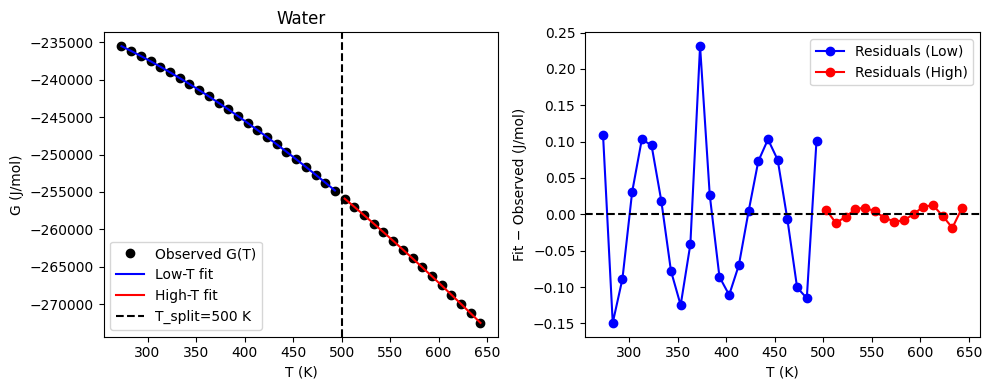

→ Fitting NH3


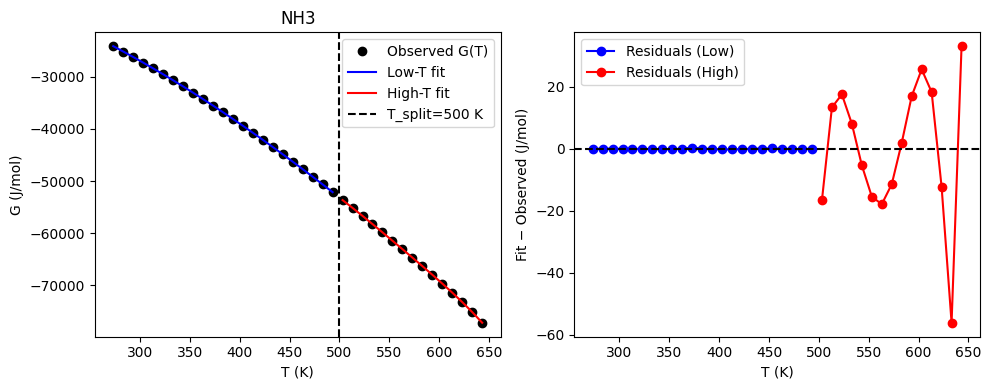

→ Fitting Acetlyne/ethyne


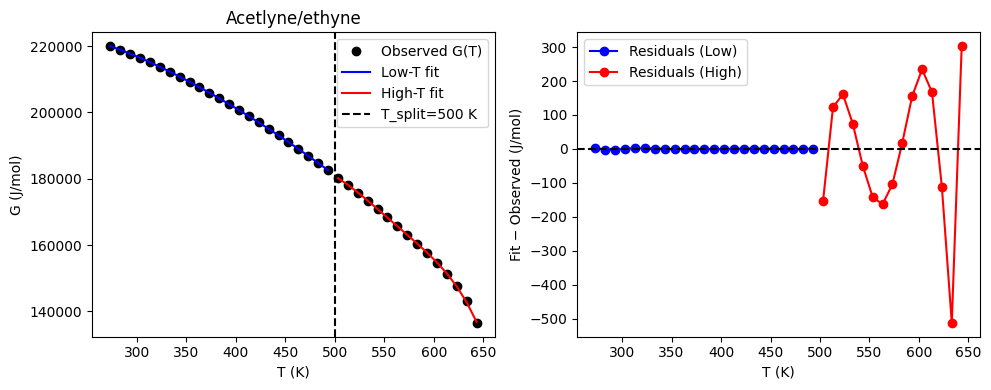

→ Fitting HCN


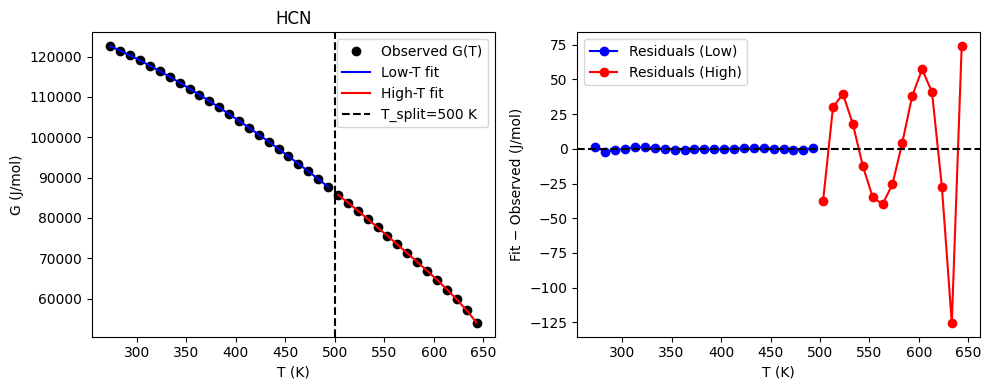

→ Fitting Formaldehyde


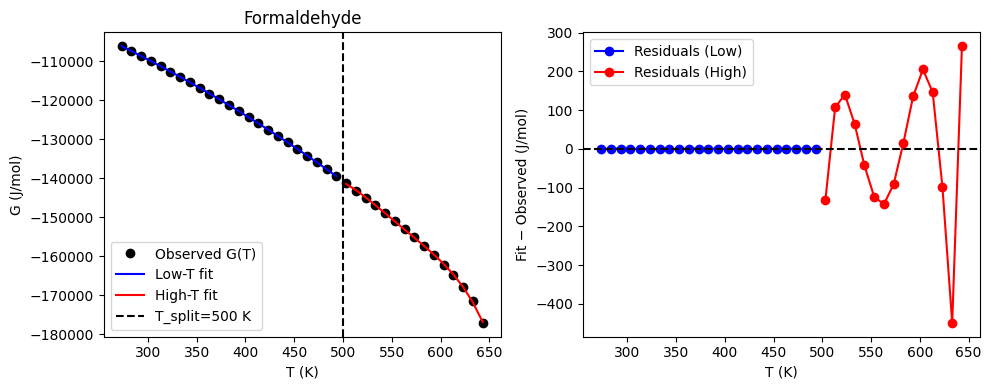

→ Fitting Adenine


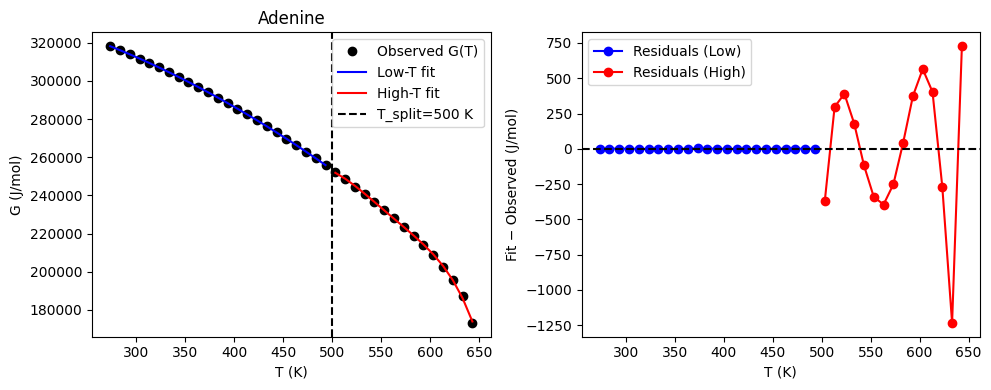

→ Fitting Guanine


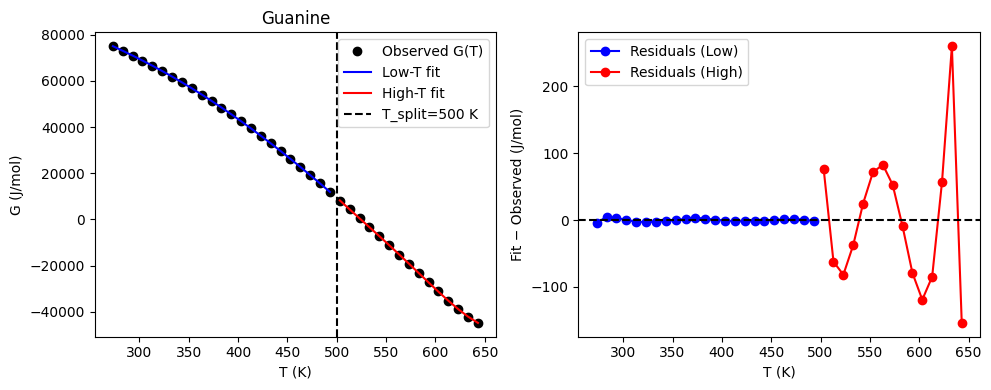

→ Fitting Cytosine


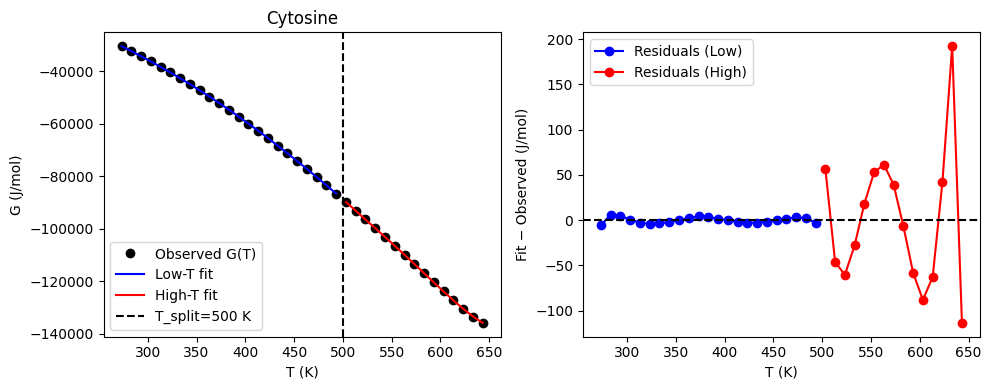

→ Fitting H2


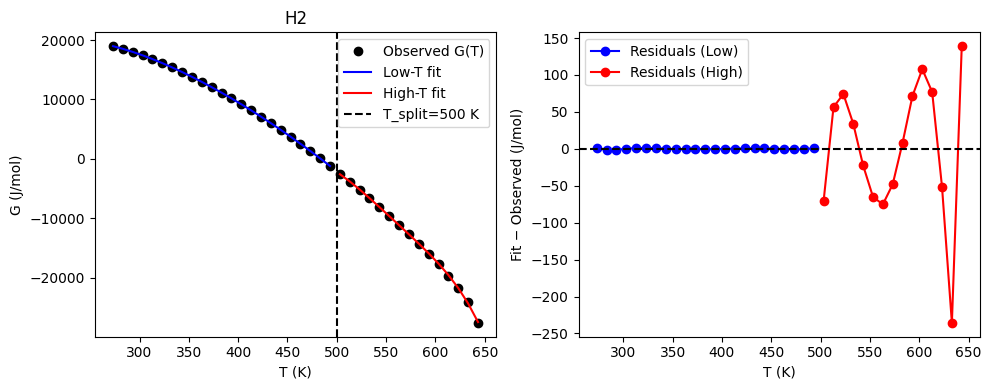

→ Fitting glycine


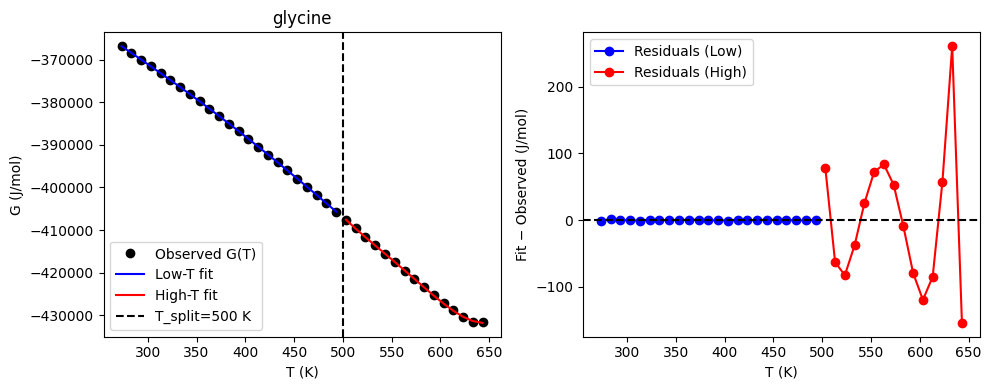

→ Fitting alanine


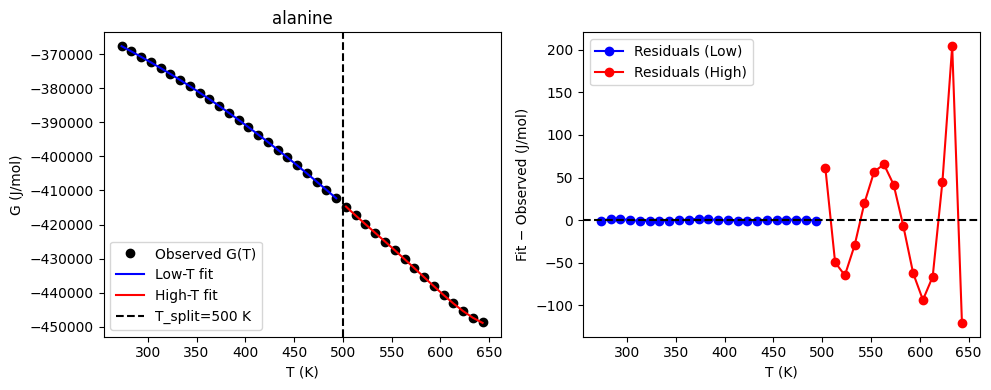

→ Fitting arginine


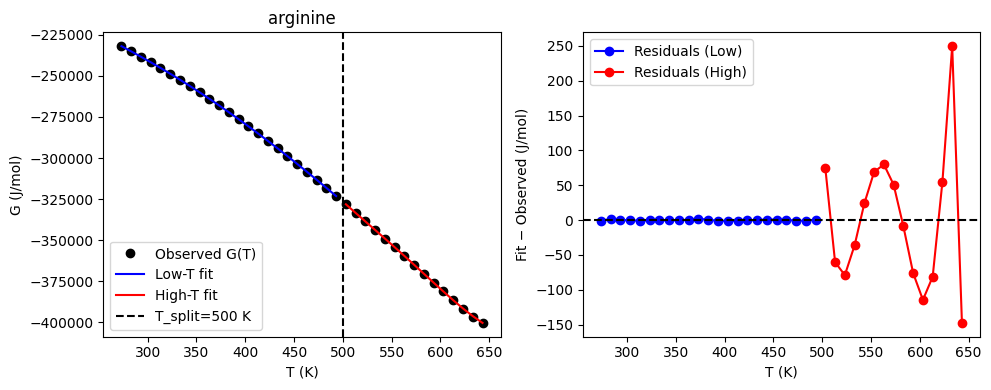

→ Fitting asparagine


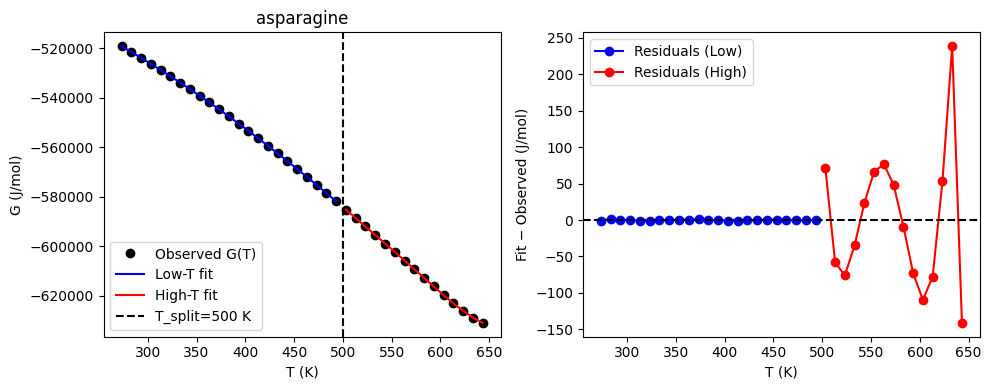

→ Fitting aspartic acid


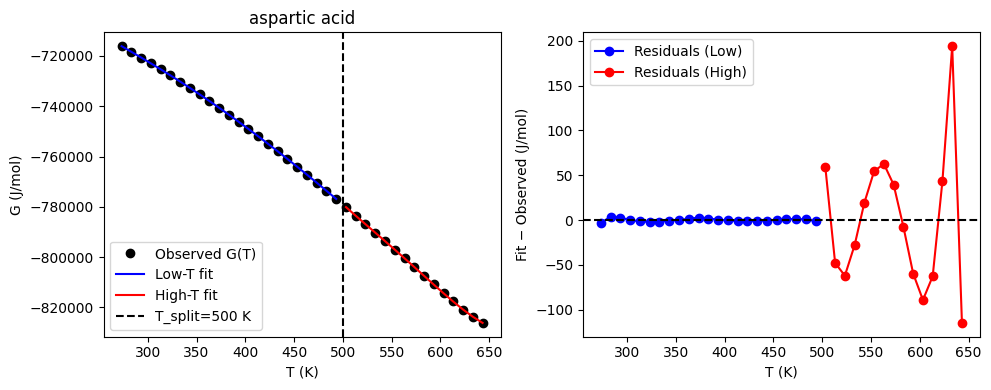

→ Fitting cysteine


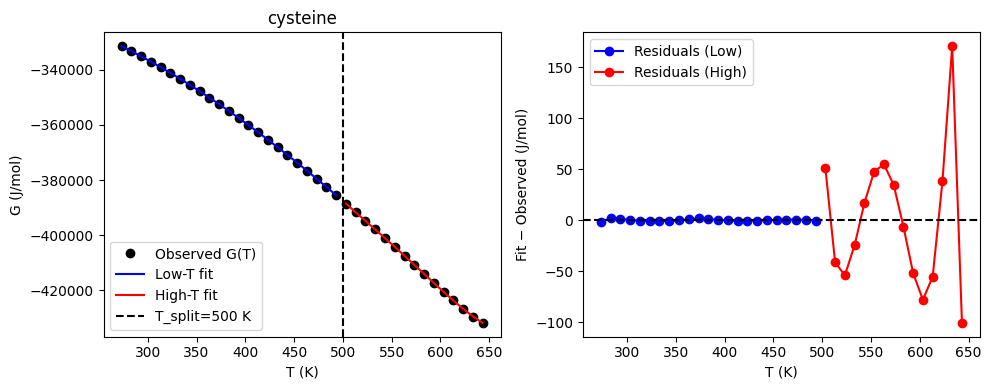

→ Fitting glutamic acid


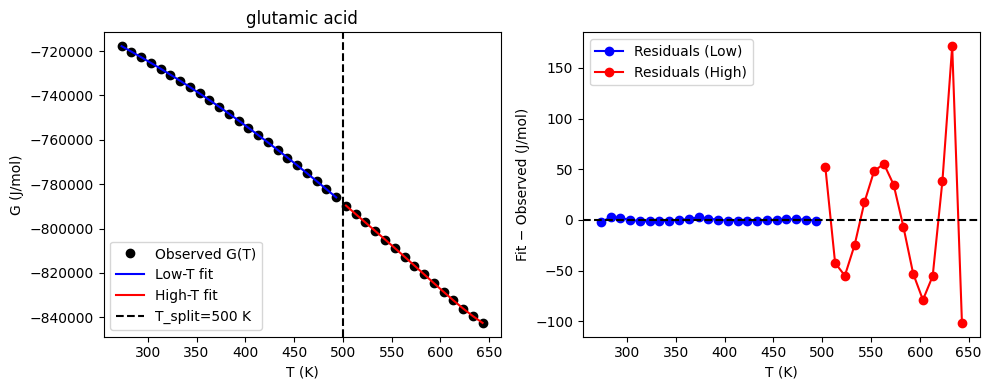

→ Fitting glutamine


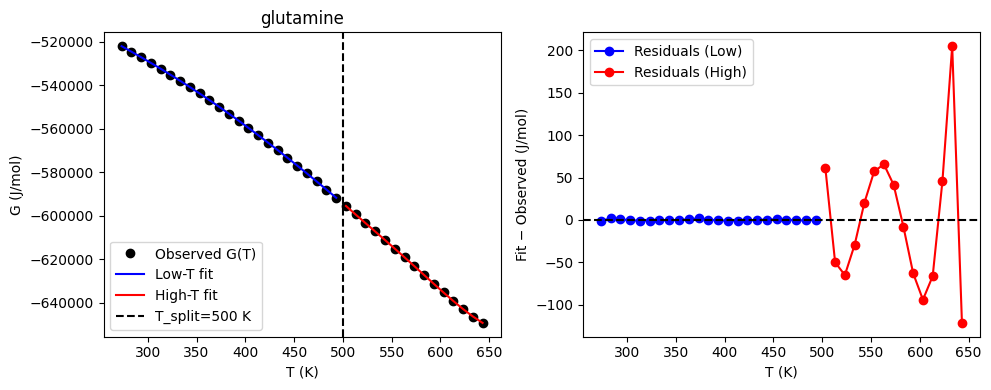

→ Fitting histidine


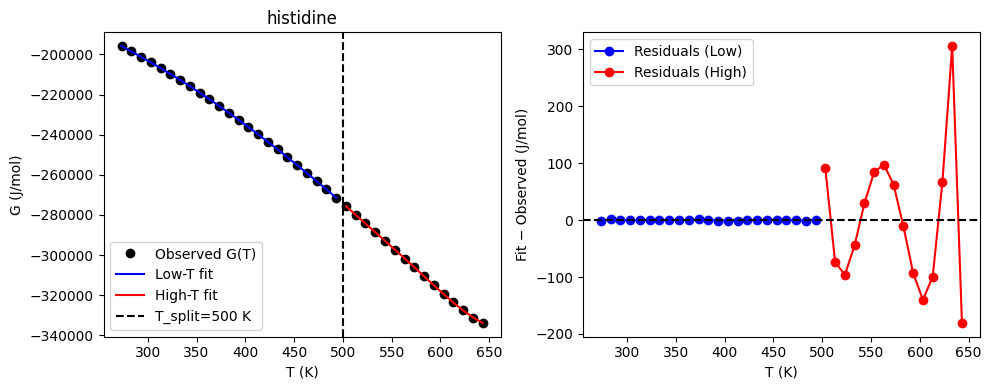

→ Fitting isoleucine


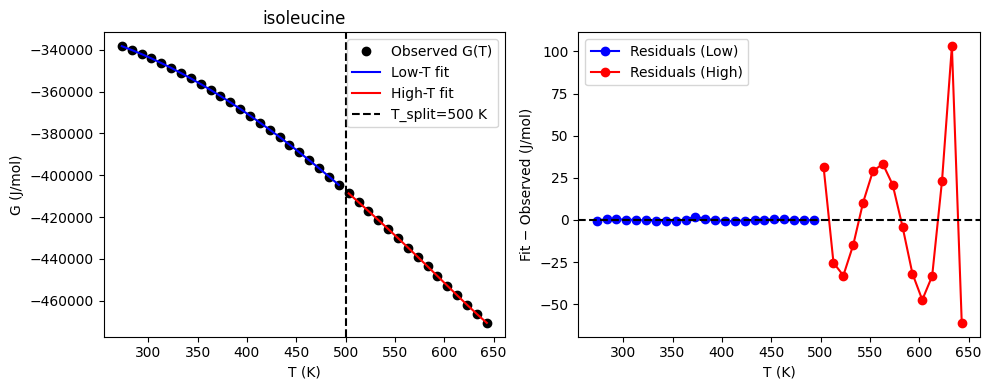

→ Fitting leucine


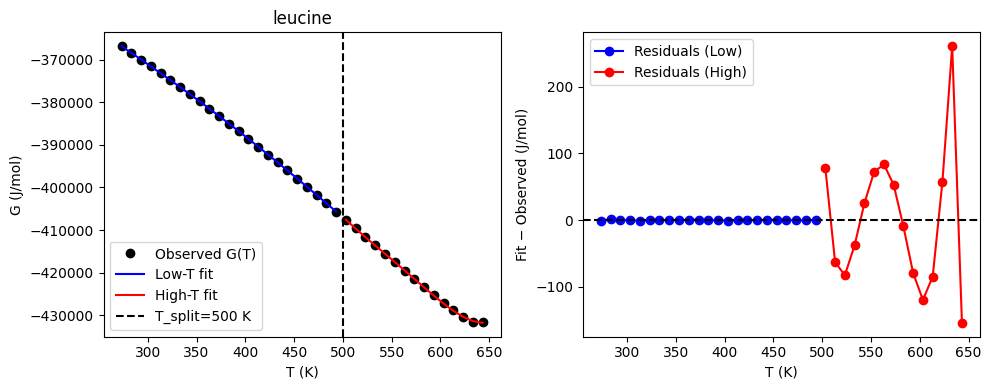

→ Fitting lysine


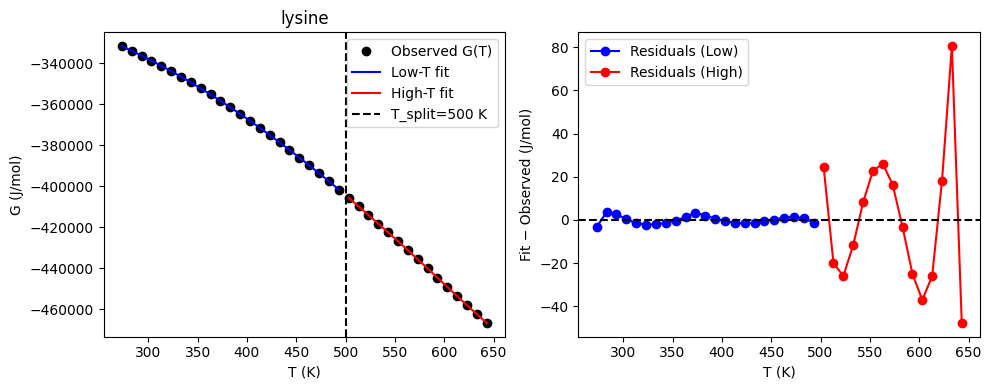

→ Fitting methionine


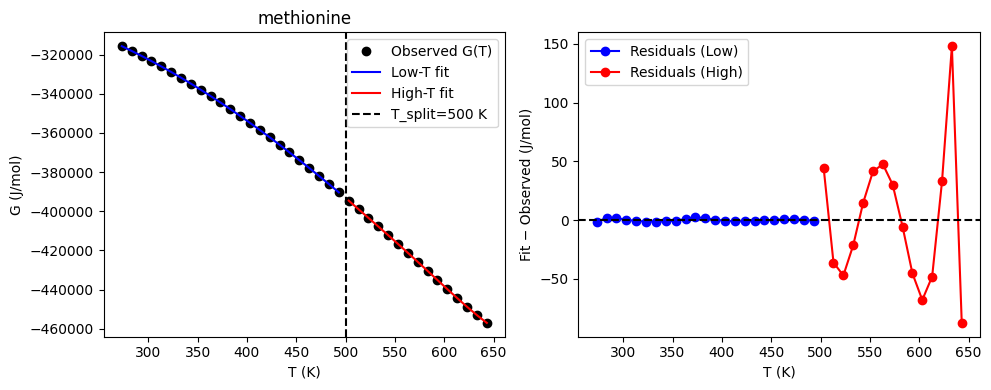

→ Fitting phenylalanine


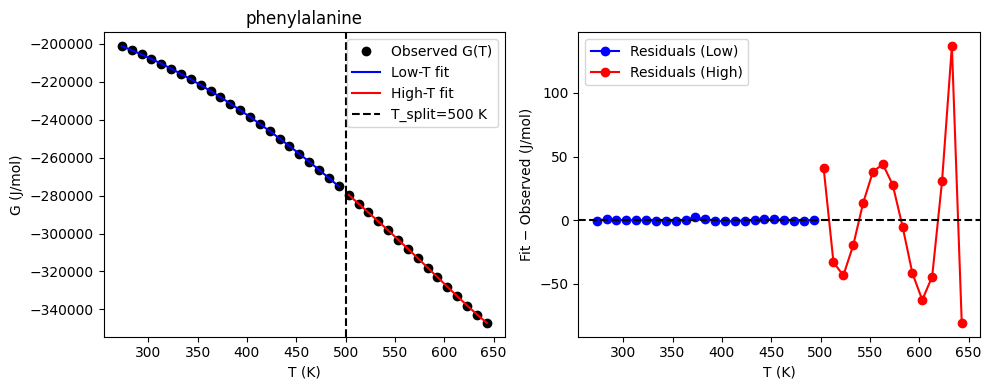

→ Fitting proline


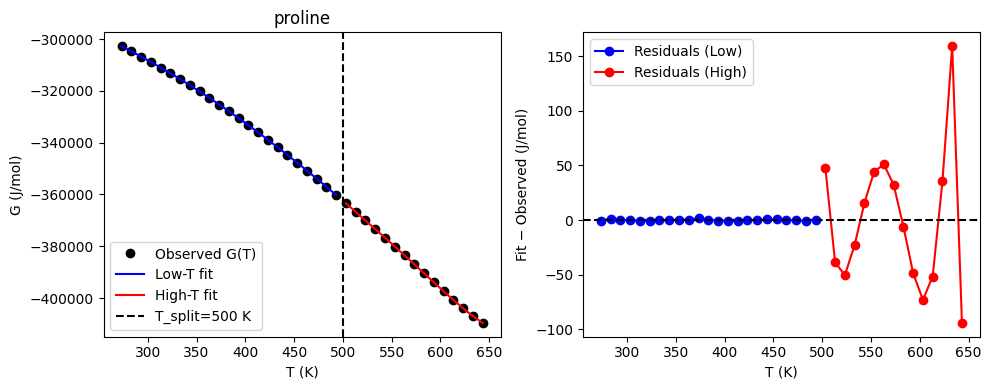

→ Fitting serine


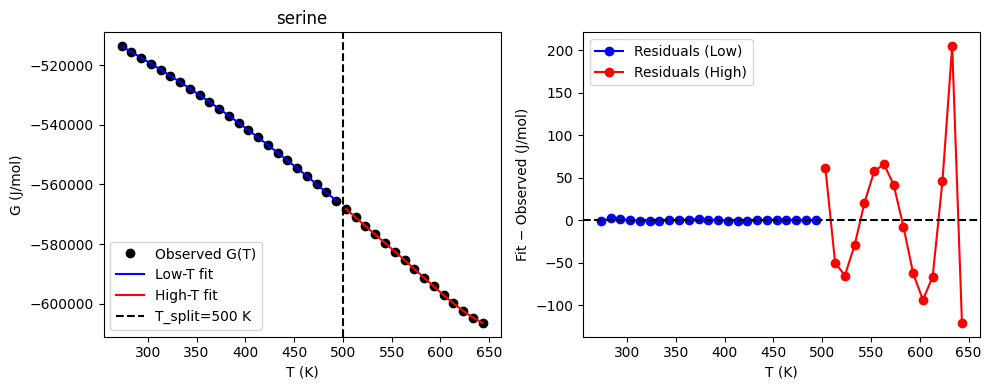

→ Fitting threonine


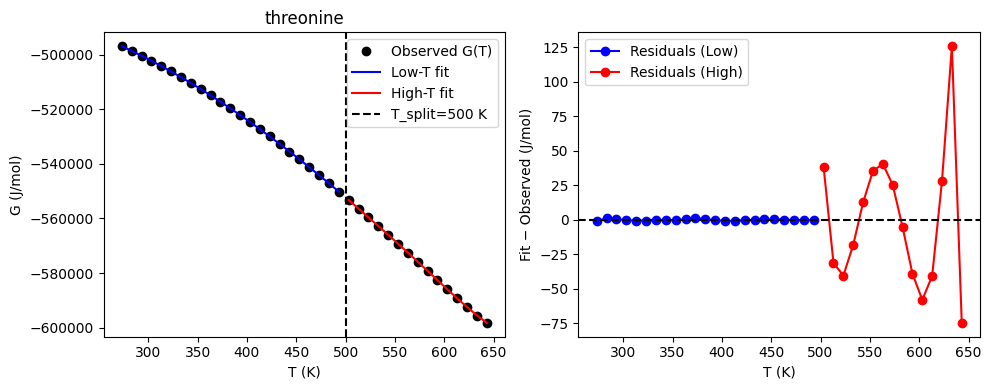

→ Fitting tryptophan


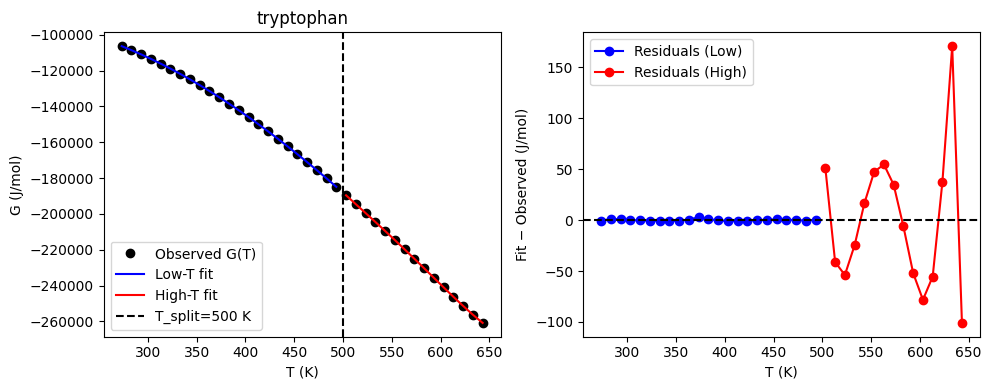

→ Fitting tyrosine


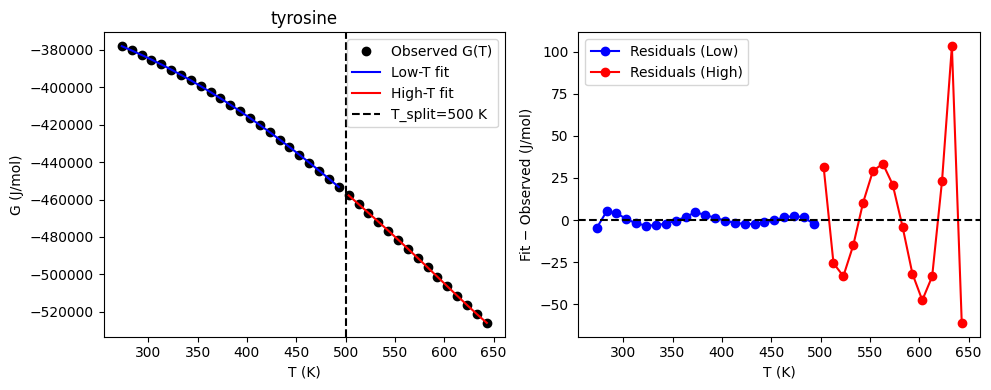

→ Fitting valine


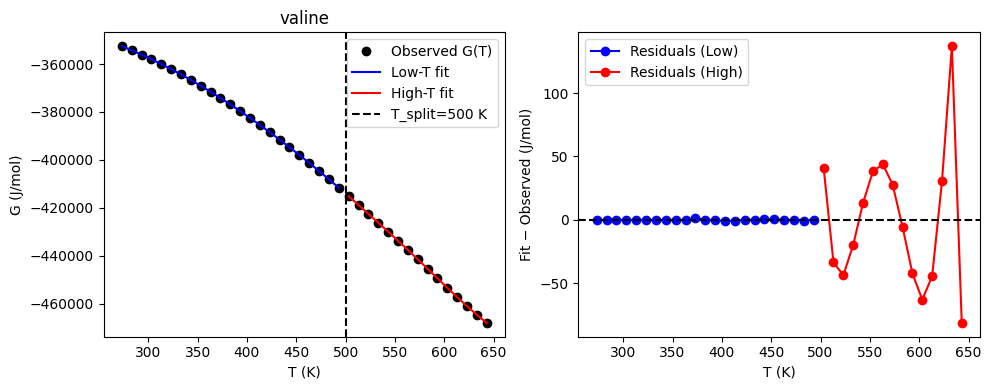

→ Fitting beta-alanine


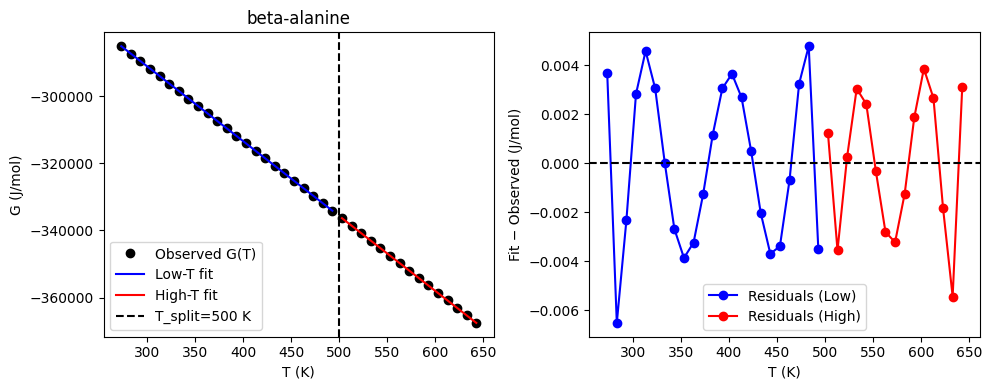

→ Fitting AAH


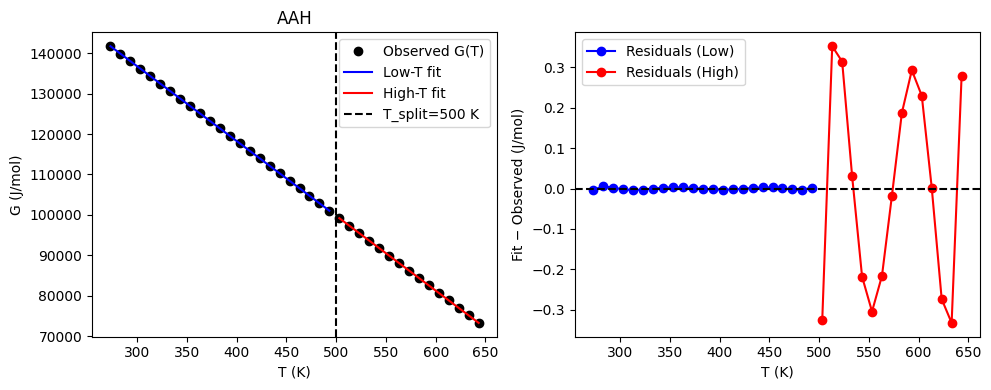

→ Fitting 2AH


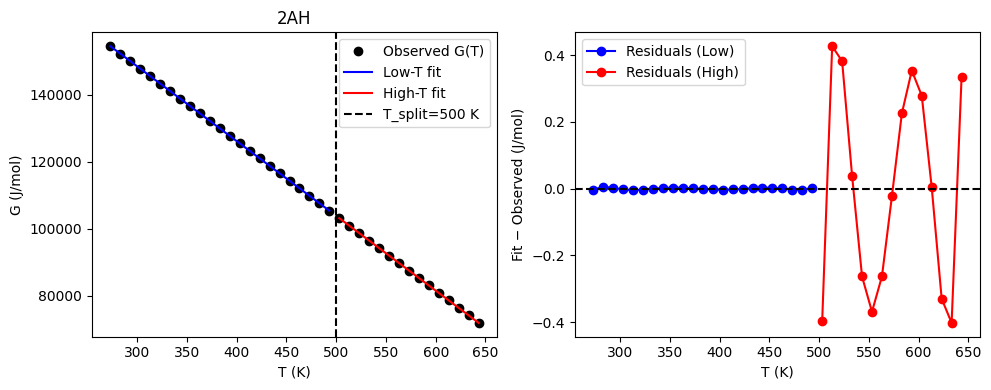

→ Fitting Ethanamine


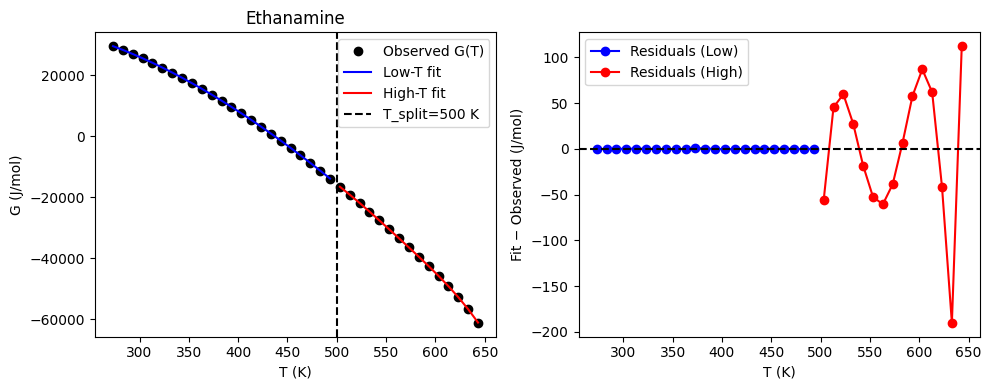


All coefficients saved to nasa9_coefficients.txt


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

# Universal gas constant in J/(mol·K)
R_GAS = 8.3144621


def nasa9_properties(a, T):
    """
    Compute H(T) and S(T) (per mole) from NASA9-style coefficients.

    Parameters
    ----------
    a : array-like of shape (9,)
        NASA9 coefficients [a0, ..., a8].
    T : array-like
        Temperatures in K.

    Returns
    -------
    H : ndarray
        Enthalpy in J/mol.
    S : ndarray
        Entropy in J/(mol·K).

    Notes
    -----
    This follows the NASA9 functional forms for H/(R·T) and S/R:
        H/(R·T) = (-a0/T^2) + a1*ln(T)/T + a2 + (a3/2)T + (a4/3)T^2 + (a5/4)T^3 + (a6/5)T^4 + a7/T
        S/R     = (-0.5*a0/T^2) - a1/T + a2*ln(T) + a3*T + (a4/2)T^2 + (a5/3)T^3 + (a6/4)T^4 + a8
    Cp expressions are not used in this fitting workflow.
    """
    a0, a1, a2, a3, a4, a5, a6, a7, a8 = a
    T = np.asarray(T, dtype=float)

    lnT    = np.log(T)
    T_inv  = 1.0 / T
    T_inv2 = T_inv * T_inv

    # H/(R·T)
    H_RT = (-a0 * T_inv2
            + a1 * lnT * T_inv
            + a2
            + (a3 / 2.0) * T
            + (a4 / 3.0) * T**2
            + (a5 / 4.0) * T**3
            + (a6 / 5.0) * T**4
            + a7 * T_inv)

    # S/R
    S_R = (-0.5 * a0 * T_inv2
           - a1 * T_inv
           + a2 * lnT
           + a3 * T
           + (a4 / 2.0) * T**2
           + (a5 / 3.0) * T**3
           + (a6 / 4.0) * T**4
           + a8)

    # Convert to dimensional H and S
    H = H_RT * R_GAS * T      # J/mol
    S = S_R  * R_GAS          # J/(mol·K)
    return H, S


def compute_gibbs(a, T):
    """
    Compute Gibbs free energy: G(T) = H(T) − T·S(T).

    Parameters
    ----------
    a : array-like of shape (9,)
        NASA9 coefficients.
    T : array-like
        Temperatures in K.

    Returns
    -------
    G : ndarray
        Gibbs free energy in J/mol.
    """
    H, S = nasa9_properties(a, T)
    return H - T * S


def residuals(a, T, G_obs):
    """
    Residuals between model-predicted G(T) and observed G(T).

    Parameters
    ----------
    a : array-like of shape (9,)
        Current guess for NASA9 coefficients.
    T : array-like
        Temperatures in K.
    G_obs : array-like
        Observed Gibbs free energy in J/mol.

    Returns
    -------
    r : ndarray
        Residuals = G_model(T) − G_obs(T).
    """
    return compute_gibbs(a, T) - G_obs


def fit_nasa9(T, G, T_split=500.0):
    """
    Fit two NASA9 coefficient sets: one below/at T_split, one above T_split.

    Parameters
    ----------
    T : ndarray
        Temperatures in K.
    G : ndarray
        Observed Gibbs free energies (J/mol) at the same T points.
    T_split : float, optional
        Temperature (K) at which to split the fit (default 500.0).

    Returns
    -------
    a_low : ndarray, shape (9,)
        NASA9 coefficients for T ≤ T_split.
    a_high : ndarray, shape (9,)
        NASA9 coefficients for T > T_split.
    """
    mask_low  = T <= T_split
    mask_high = T >  T_split

    # Initial guess: zeros (can be customized if needed)
    a0 = np.zeros(9)

    # Independent least-squares fits on each side of the split
    res_low  = least_squares(residuals, a0, args=(T[mask_low],  G[mask_low]))
    res_high = least_squares(residuals, a0, args=(T[mask_high], G[mask_high]))
    return res_low.x, res_high.x


def load_csv(csv_file):
    """
    Load the Gibbs energy CSV, returning temperatures and a dict of species data.

    Expected file layout:
      - 1st line: comment
      - 2nd line: comma-only placeholders (blank line)
      - 3rd line: header with 'T (K)' (or similar) and species columns
      - Data rows follow

    Parameters
    ----------
    csv_file : str or Path
        Path to the CSV file (e.g., 'Gibbs_Energies_All.csv').

    Returns
    -------
    T : ndarray
        Temperatures in K.
    species : dict[str, ndarray]
        Mapping of species name -> Gibbs free energy values (J/mol) at each T.

    Notes
    -----
    - The loader robustly identifies the temperature column by looking for
      headers that normalize to 't(k)' or 't'.
    - Columns that are empty or 'Unnamed: ...' placeholders are dropped.
    """
    # Read the actual header on the 3rd line (skip comment + blank commas line)
    df = pd.read_csv(csv_file, skiprows=2, header=0)

    # Drop empty/placeholder columns
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed") or df[c].isna().all()]
    df = df.drop(columns=drop_cols)

    # Normalize column names (trim spaces)
    df.columns = [c.strip() for c in df.columns]

    # Identify the temperature column robustly
    temp_candidates = [c for c in df.columns if c.replace(" ", "").lower() in ("t(k)", "t")]
    temp_col = temp_candidates[0] if temp_candidates else df.columns[0]

    # Ensure numeric data
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(how="all")

    # Extract arrays
    T = df[temp_col].to_numpy()
    species = {c: df[c].to_numpy() for c in df.columns if c != temp_col}

    # Safety: in case a temp-like column slipped into species (belt & suspenders)
    for k in list(species.keys()):
        if k.replace(" ", "").lower() in ("t(k)", "t"):
            species.pop(k)

    return T, species


def run_all(csv_file, T_split=500.0, output_file='nasa9_coefficients.txt'):
    """
    Orchestrate the full workflow:
      1) Load data
      2) Fit NASA9 coefficients for each species on low/high ranges
      3) Save coefficients
      4) Plot G-vs-T and residuals

    Parameters
    ----------
    csv_file : str or Path
        Path to the CSV file (e.g., 'Gibbs_Energies_All.csv').
    T_split : float, optional
        Temperature (K) at which to split the fit (default 500.0).
    output_file : str, optional
        Text file to save coefficients (default 'nasa9_coefficients.txt').
    """
    T, species = load_csv(csv_file)

    with open(output_file, 'w') as fout:
        for name, G in species.items():
            print(f"→ Fitting {name}")

            # Fit low/high ranges
            a_low, a_high = fit_nasa9(T, G, T_split=T_split)

            # Write coefficients for this species
            fout.write(f"{name}\n")
            fout.write("[" + ", ".join(f"{x:.6e}" for x in a_low)  + "]\n")
            fout.write("[" + ", ".join(f"{x:.6e}" for x in a_high) + "]\n\n")

            # Compute fitted curves for plotting
            mask_low  = T <= T_split
            mask_high = T >  T_split
            G_low  = compute_gibbs(a_low,  T[mask_low])
            G_high = compute_gibbs(a_high, T[mask_high])

            # --- Plot: Observed vs Fitted and residuals ---
            plt.figure(figsize=(10, 4))

            # (1) G vs T
            plt.subplot(1, 2, 1)
            plt.plot(T,            G,        'ko', label='Observed G(T)')
            plt.plot(T[mask_low],  G_low,    'b-', label='Low-T fit')
            plt.plot(T[mask_high], G_high,   'r-', label='High-T fit')
            plt.axvline(T_split, color='k', ls='--', label=f'T_split={T_split:g} K')
            plt.xlabel('T (K)')
            plt.ylabel('G (J/mol)')
            plt.title(name)
            plt.legend()

            # (2) Residuals
            res_low  = G_low  - G[mask_low]
            res_high = G_high - G[mask_high]

            plt.subplot(1, 2, 2)
            plt.plot(T[mask_low],  res_low,  'bo-', label='Residuals (Low)')
            plt.plot(T[mask_high], res_high, 'ro-', label='Residuals (High)')
            plt.axhline(0, color='k', ls='--')
            plt.xlabel('T (K)')
            plt.ylabel('Fit − Observed (J/mol)')
            plt.legend()

            plt.tight_layout()
            plt.show()

    print(f"\nAll coefficients saved to {output_file}")


# === Parameters ===
# The file named 'Gibbs_Energies_All.csv' contains all Gibbs energy data (J/mol)
# that this code will ingest to perform the polynomial fitting.
csv_file    = 'Gibbs_Energies_All.csv'      # path to your data file
T_split     = 500.0                         # split temperature (K) for low/high fits
output_file = 'nasa9_coefficients.txt'      # where to write coefficients

# Run everything
run_all(csv_file, T_split=T_split, output_file=output_file)
